# Phase 4 — Classical ML Models

Train and evaluate three classical ML models on the 45-dim handcrafted features.

Models:
- **Logistic Regression** — linear baseline
- **SVM (RBF kernel)** — non-linear, strong on tabular features
- **Random Forest** — ensemble, provides feature importances

Protocol:
- Features loaded from `outputs/results/features_cache.pkl` (no re-extraction)
- Stratified 5-fold CV + GridSearchCV for tuning — on **train split only**
- Final evaluation on **held-out test split** (never seen during tuning)
- Metrics: ROC-AUC (primary), Sensitivity, Specificity, F1, Accuracy


In [1]:
import sys
from pathlib import Path

def _find_project_root(start, marker='config.py'):
    for parent in [start, *start.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f'Cannot find project root from {start}')

PROJECT_ROOT = _find_project_root(Path().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')

Project root: D:\Machine Learning\glaucoma detection project


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay

from config import FEATURES_CACHE, FIGURES_DIR, RESULTS_DIR, SEED
from features.feature_extractor import feature_names
from models.classical_ml import (
    train_all_models,
    evaluate_on_test,
    get_feature_importances,
    load_trained_models,
)

plt.rcParams['figure.dpi'] = 120
print('Imports OK')

Imports OK


## 4.1 Load feature cache

In [4]:
cache    = joblib.load(FEATURES_CACHE)
X        = cache['X']
y        = cache['y']
names    = cache['names']
valid_df = cache['valid_df']

print(f'Feature matrix : {X.shape}')
print(f'Labels         : {np.bincount(y)}  (Normal={int((y==0).sum())}, Glaucoma={int((y==1).sum())})')
print(f'NaN in X       : {np.isnan(X).sum()}')

Feature matrix : (4730, 45)
Labels         : [2392 2338]  (Normal=2392, Glaucoma=2338)
NaN in X       : 0


## 4.2 Build train / val / test splits

In [5]:
# Use the split column already in valid_df (assigned during dataset loading)
train_mask = valid_df['split'] == 'train'
val_mask   = valid_df['split'] == 'val'
test_mask  = valid_df['split'] == 'test'

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f'Train : {X_train.shape}  Glaucoma={y_train.sum()}  Normal={(y_train==0).sum()}')
print(f'Val   : {X_val.shape}    Glaucoma={y_val.sum()}    Normal={(y_val==0).sum()}')
print(f'Test  : {X_test.shape}   Glaucoma={y_test.sum()}   Normal={(y_test==0).sum()}')

Train : (2749, 45)  Glaucoma=1372  Normal=1377
Val   : (931, 45)    Glaucoma=466    Normal=465
Test  : (1050, 45)   Glaucoma=500   Normal=550


## 4.3 Train all models
Runs 5-fold GridSearchCV for each model on the training split.  
Expect ~5–10 minutes total. SVM is the slowest.

In [6]:
# Combine train + val for the tuning phase
# (val is used only for CNN early stopping — for classical ML we give more data to CV)
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

print(f'Train+Val for CV: {X_trainval.shape}')
trained = train_all_models(X_trainval, y_trainval, cv_folds=5)

Train+Val for CV: (3680, 45)

────────────────────────────────────────────────────
  Training: LogisticRegression
────────────────────────────────────────────────────
Fitting 5 folds for each of 4 candidates, totalling 20 fits


d:\Machine Learning\glaucoma detection project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


  Best params : {'clf__C': 1.0, 'clf__penalty': 'l2'}
  CV AUC      : 0.7720
  Saved → D:\Machine Learning\glaucoma detection project\outputs\models\LogisticRegression_best.pkl

────────────────────────────────────────────────────
  Training: SVM_RBF
────────────────────────────────────────────────────
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  Best params : {'clf__C': 10.0, 'clf__gamma': 'auto'}
  CV AUC      : 0.8490
  Saved → D:\Machine Learning\glaucoma detection project\outputs\models\SVM_RBF_best.pkl

────────────────────────────────────────────────────
  Training: RandomForest
────────────────────────────────────────────────────
Fitting 5 folds for each of 12 candidates, totalling 60 fits
  Best params : {'clf__max_depth': 20, 'clf__min_samples_split': 2, 'clf__n_estimators': 300}
  CV AUC      : 0.8425
  Saved → D:\Machine Learning\glaucoma detection project\outputs\models\RandomForest_best.pkl


## 4.4 CV results summary

In [7]:
print(f'\n{"Model":<22} {"CV AUC (mean ± std)"}')
print('─' * 45)
for name, res in trained.items():
    print(f'{name:<22} {res["cv_auc_mean"]:.4f} ± {res["cv_auc_std"]:.4f}')
    print(f'  Best params: {res["best_params"]}')


Model                  CV AUC (mean ± std)
─────────────────────────────────────────────
LogisticRegression     0.7720 ± 0.0113
  Best params: {'clf__C': 1.0, 'clf__penalty': 'l2'}
SVM_RBF                0.8490 ± 0.0142
  Best params: {'clf__C': 10.0, 'clf__gamma': 'auto'}
RandomForest           0.8425 ± 0.0117
  Best params: {'clf__max_depth': 20, 'clf__min_samples_split': 2, 'clf__n_estimators': 300}


## 4.5 Test set evaluation

In [8]:
results_df, roc_data = evaluate_on_test(trained, X_test, y_test)
print('\n── Test Set Results ──')
display(results_df[['model', 'auc', 'sensitivity', 'specificity', 'f1', 'accuracy', 'cv_auc']])


[LogisticRegression]
  AUC         : 0.7126
  Sensitivity : 0.6700
  Specificity : 0.6491
  F1          : 0.6518
  Accuracy    : 0.6590

[SVM_RBF]
  AUC         : 0.7888
  Sensitivity : 0.7560
  Specificity : 0.6818
  F1          : 0.7179
  Accuracy    : 0.7171

[RandomForest]
  AUC         : 0.7674
  Sensitivity : 0.7140
  Specificity : 0.6891
  F1          : 0.6946
  Accuracy    : 0.7010

Results saved → D:\Machine Learning\glaucoma detection project\outputs\results\classical_ml_results.csv

── Test Set Results ──


,model,auc,sensitivity,specificity,f1,accuracy,cv_auc
0,LogisticRegression,0.7126,0.670,0.6491,0.6518,0.6590,0.7720 ± 0.0113
1,SVM_RBF,0.7888,0.756,0.6818,0.7179,0.7171,0.8490 ± 0.0142
2,RandomForest,0.7674,0.714,0.6891,0.6946,0.7010,0.8425 ± 0.0117


## 4.6 ROC curves — all models

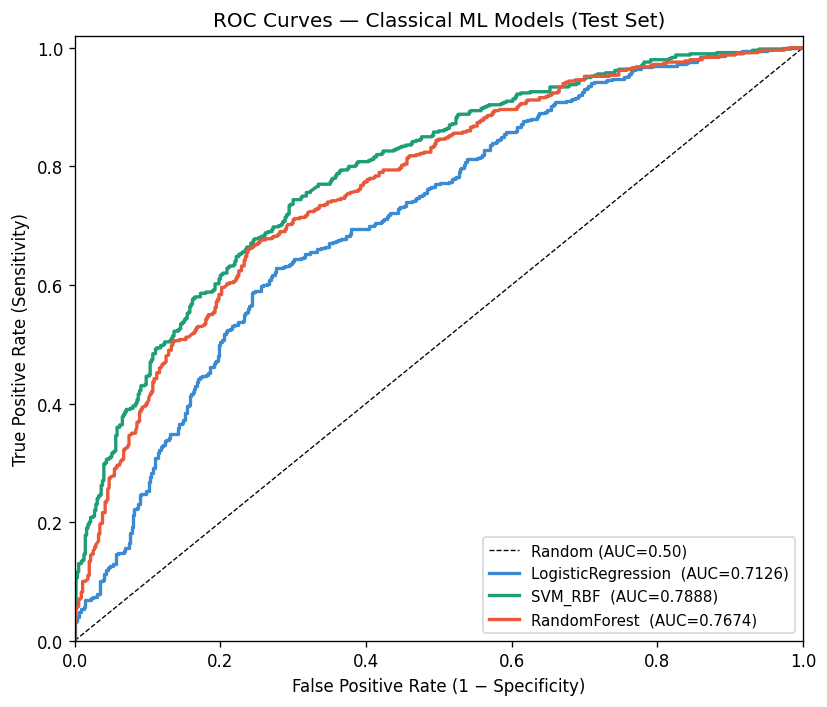

In [9]:
colours = {'LogisticRegression': '#3B8BD4', 'SVM_RBF': '#1D9E75', 'RandomForest': '#E8593C'}

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0,1], [0,1], 'k--', linewidth=0.8, label='Random (AUC=0.50)')

for name, data in roc_data.items():
    ax.plot(data['fpr'], data['tpr'],
            color=colours.get(name, 'gray'),
            linewidth=2,
            label=f"{name}  (AUC={data['auc']:.4f})")

ax.set_xlabel('False Positive Rate (1 − Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curves — Classical ML Models (Test Set)')
ax.legend(fontsize=9, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'classical_ml_roc_curves.png', bbox_inches='tight')
plt.show()

## 4.7 Confusion matrices — all models

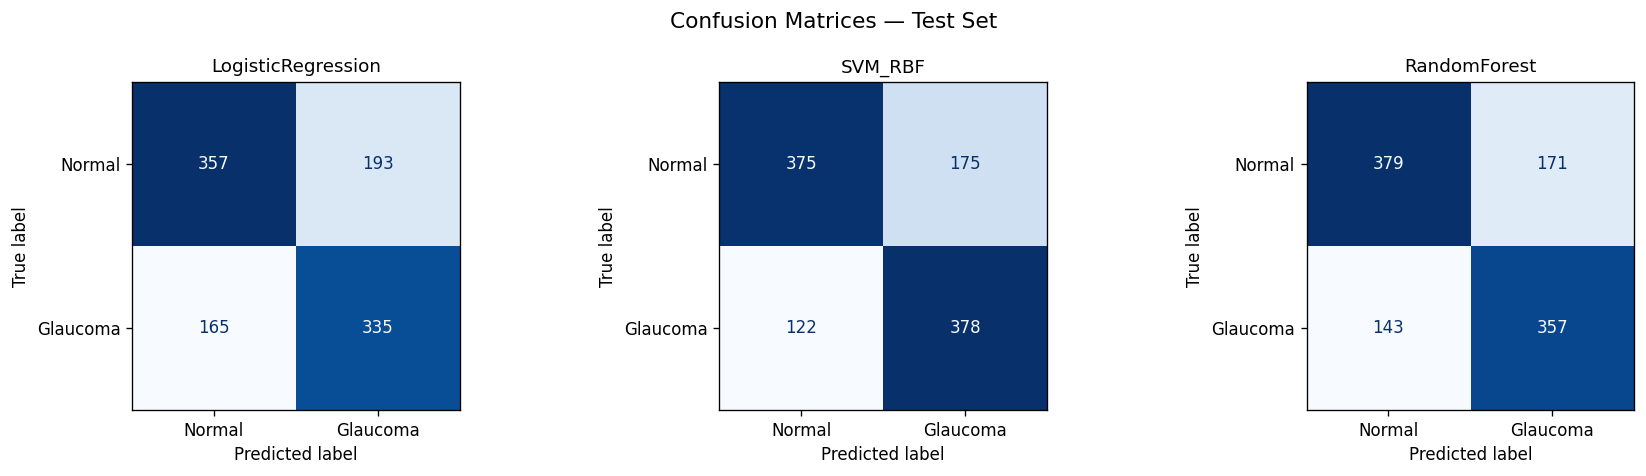

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, res) in zip(axes, trained.items()):
    model  = res['best_estimator']
    y_pred = model.predict(X_test)
    disp   = ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Normal', 'Glaucoma'],
        cmap='Blues',
        ax=ax,
        colorbar=False,
    )
    ax.set_title(name, fontsize=11)

plt.suptitle('Confusion Matrices — Test Set', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'classical_ml_confusion_matrices.png', bbox_inches='tight')
plt.show()

## 4.8 Random Forest — feature importances

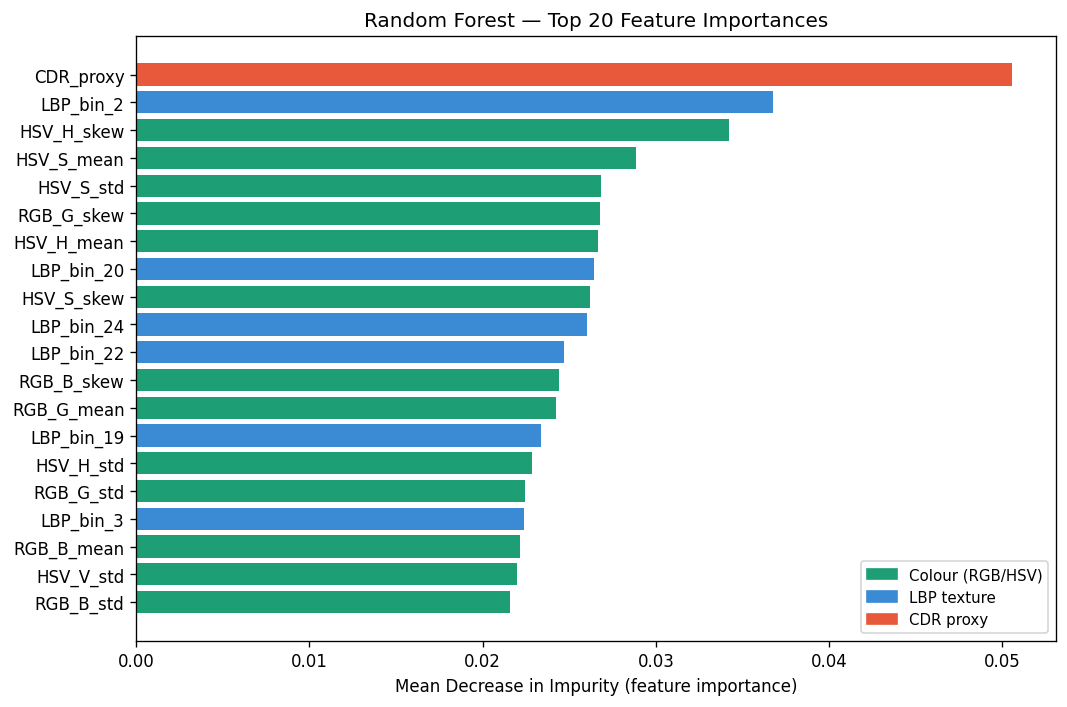

   feature  importance
 CDR_proxy    0.050577
 LBP_bin_2    0.036751
HSV_H_skew    0.034216
HSV_S_mean    0.028879
 HSV_S_std    0.026851
RGB_G_skew    0.026764
HSV_H_mean    0.026633
LBP_bin_20    0.026440
HSV_S_skew    0.026171
LBP_bin_24    0.026035
LBP_bin_22    0.024687
RGB_B_skew    0.024418
RGB_G_mean    0.024225
LBP_bin_19    0.023359
 HSV_H_std    0.022824
 RGB_G_std    0.022457
 LBP_bin_3    0.022382
RGB_B_mean    0.022171
 HSV_V_std    0.021989
 RGB_B_std    0.021587


In [11]:
fi_df = get_feature_importances(trained, names, top_n=20)

# Colour bars by feature group
def feat_colour(fname):
    if fname.startswith('RGB') or fname.startswith('HSV'): return '#1D9E75'
    if fname.startswith('LBP'):                             return '#3B8BD4'
    return '#E8593C'  # CDR

bar_colours = [feat_colour(n) for n in fi_df['feature']]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(fi_df['feature'][::-1], fi_df['importance'][::-1], color=bar_colours[::-1])
ax.set_xlabel('Mean Decrease in Impurity (feature importance)')
ax.set_title('Random Forest — Top 20 Feature Importances')

ax.legend(handles=[
    mpatches.Patch(color='#1D9E75', label='Colour (RGB/HSV)'),
    mpatches.Patch(color='#3B8BD4', label='LBP texture'),
    mpatches.Patch(color='#E8593C', label='CDR proxy'),
], fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'rf_feature_importances.png', bbox_inches='tight')
plt.show()

print(fi_df.to_string(index=False))

## 4.9 Per-dataset breakdown — best model on test set

In [12]:
from sklearn.metrics import roc_auc_score
from models.classical_ml import compute_metrics

# Pick best model by test AUC
best_name = results_df.loc[results_df['auc'].idxmax(), 'model']
best_model = trained[best_name]['best_estimator']
print(f'Best model: {best_name}')

test_df = valid_df[test_mask].copy()
test_df['y_pred'] = best_model.predict(X_test)
test_df['y_prob'] = best_model.predict_proba(X_test)[:, 1]

print(f'\n{"Dataset":<12} {"AUC":>8} {"Sensitivity":>13} {"Specificity":>13} {"N":>6}')
print('─' * 56)
for ds_name in sorted(test_df['dataset'].unique()):
    sub = test_df[test_df['dataset'] == ds_name]
    if sub['label'].nunique() < 2:
        print(f'{ds_name:<12}  (only one class in test split, skip)')
        continue
    m = compute_metrics(sub['label'].values, sub['y_pred'].values, sub['y_prob'].values)
    print(f'{ds_name:<12} {m["auc"]:>8.4f} {m["sensitivity"]:>13.4f} {m["specificity"]:>13.4f} {len(sub):>6}')

Best model: SVM_RBF

Dataset           AUC   Sensitivity   Specificity      N
────────────────────────────────────────────────────────
ACRIMA         0.9888        0.9831        0.9362    106
AIROGS         0.7773        0.7143        0.7039    770
RIMONE         0.7334        0.8036        0.5085    174


## 4.10 Publication-ready results table

In [13]:
pub_table = results_df[['model', 'auc', 'sensitivity', 'specificity', 'f1', 'accuracy', 'cv_auc']].copy()
pub_table.columns = ['Model', 'AUC', 'Sensitivity', 'Specificity', 'F1', 'Accuracy', 'CV AUC (5-fold)']
pub_table = pub_table.set_index('Model')

# Highlight best value per metric
display(pub_table.style
    .highlight_max(subset=['AUC','Sensitivity','Specificity','F1','Accuracy'], color='#d4edda')
    .format(precision=4))

pub_table.to_csv(RESULTS_DIR / 'classical_ml_pub_table.csv')
print(f'\nSaved → {RESULTS_DIR / "classical_ml_pub_table.csv"}')

,AUC,Sensitivity,Specificity,F1,Accuracy,CV AUC (5-fold)
Model,,,,,,
LogisticRegression,0.7126,0.6700,0.6491,0.6518,0.6590,0.7720 ± 0.0113
SVM_RBF,0.7888,0.7560,0.6818,0.7179,0.7171,0.8490 ± 0.0142
RandomForest,0.7674,0.7140,0.6891,0.6946,0.7010,0.8425 ± 0.0117



Saved → D:\Machine Learning\glaucoma detection project\outputs\results\classical_ml_pub_table.csv


---
## ✅ Phase 4 complete

Verify before moving on:
- All three models trained without errors
- `.pkl` model files saved in `outputs/models/`
- `classical_ml_results.csv` and `classical_ml_pub_table.csv` in `outputs/results/`
- ROC curves + confusion matrices + feature importance plots in `outputs/figures/`

**Interpreting results for the paper:**
- Classical ML AUC in the 0.55–0.70 range is expected and acceptable as a baseline
- Random Forest feature importances tell you which feature groups matter most
- CNN (Phase 5) should outperform all of these — that improvement is your paper's core contribution

**Next → `04_cnn_training.ipynb`**  
Transfer learning with ResNet18 — GPU-accelerated training with early stopping.